# Prediccion del futbol uruguayo: ID3 propio y Naive Bayes

En este notebook entrenamos dos clasificadores implementados a mano para
predecir si un partido de primera division lo gana el local (L), termina en
empate (E) o lo gana el visitante (V). Se usan partidos del campeonato
uruguayo y atributos basados solo en lo que paso antes del partido.

El recorrido es: primero los datos y los atributos, despues la forma de elegir
hiperparametros con validacion temporal, y recien al final la medicion sobre el
test de 2024-2025. Las dos implementaciones propias estan en `id3.py` (arbol) y
`naive_bayes.py` (Naive Bayes), en la misma carpeta que este notebook; todo el
pipeline que las alimenta (carga, limpieza, atributos causales,
discretizacion, folds y metricas) se define directamente en las celdas de este
notebook, para que sea autocontenido.

## 1. Configuracion

Para que este notebook corra solo necesita, en la misma carpeta:

- `id3.py` y `naive_bayes.py` (los dos clasificadores propios,
  implementados a mano);
- `futbol_uruguayo.zip` (el dataset crudo), cuyo nombre y ubicacion se
  configuran en `RAW`: el ZIP debe estar junto al notebook. Si esta en otra
  ruta se ajusta esa variable y nada mas.

Importamos las librerias de terceros (pandas, numpy, matplotlib y
scikit-learn, este ultimo solo para medir y comparar) y los dos modelos
propios. Las funciones de datos, atributos, discretizacion, folds y metricas
se definen en las secciones 1.1 a 1.5.

In [ ]:
import copy
import sys
from collections import defaultdict, deque
from dataclasses import dataclass, field
from pathlib import Path
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier

# Los dos clasificadores propios viven en esta misma carpeta (id3.py y
# naive_bayes.py); el resto del pipeline se define en las proximas celdas.
sys.path.insert(0, str(Path.cwd()))

from id3 import ID3  # noqa: E402
from naive_bayes import MEstimateCategoricalNB  # noqa: E402

## El dataset crudo debe estar en la MISMA carpeta que este notebook, con el
## nombre futbol_uruguayo.zip. Si lo guardas en otra ruta, ajusta RAW aca.
RAW = Path('futbol_uruguayo.zip')
CLASSES = ['E', 'L', 'V']
RANDOM_STATE = 42
pd.set_option('display.max_columns', 30)


def entropia(series):
    """Entropia de Shannon en bits de una serie de etiquetas."""
    probs = series.value_counts(normalize=True)
    return float(-(probs * np.log2(probs)).sum())

### 1.1. Datos: carga y limpieza (definiciones)

El ZIP original se lee en memoria, se validan las columnas, se quitan los
partidos duplicados y los dudosos, y se descartan los definidos en alargue o
penales (su resultado no representa los 90 minutos). La clase `winner` se
deriva exclusivamente de los goles (`gh`, `ga`): `L` gano el local, `V` gano
el visitante, `E` empate. Los goles nunca son atributos del modelo: solo
sirven para la etiqueta y para los historiales de partidos anteriores.

In [ ]:
_UNUSED_COLUMNS = {'away_code',
 'away_continent',
 'away_country',
 'away_ident',
 'competition',
 'continent',
 'home_code',
 'home_continent',
 'home_country',
 'home_ident',
 'level'}


def load_raw_matches(source):
    """Lee el ZIP original (un CSV) sin modificar los registros.

    gh/ga/winner se usan solo para construir la etiqueta y auditar; nunca
    entran al modelo como atributos.
    """
    path = Path(source)
    with zipfile.ZipFile(path) as archive:
        csv_members = [
            name for name in archive.namelist() if name.lower().endswith(".csv")
        ]
        with archive.open(csv_members[0]) as stream:
            return pd.read_csv(stream, encoding="utf-8-sig")


def load_clean_matches(source):
    """Aplica la politica de auditoria antes de crear targets o historiales."""
    return _clean_matches(load_raw_matches(source))


def _normalize_matches(raw):
    """Limpieza minima: nombres de columnas, tipos y goles enteros."""
    frame = raw.copy().reset_index(drop=True)
    frame.columns = [str(column).strip() for column in frame.columns]
    for column in frame.select_dtypes(include=["object", "string"]).columns:
        frame[column] = frame[column].astype("string").str.strip()
    frame["date"] = pd.to_datetime(frame["date"], format="%Y-%m-%d", errors="raise")
    frame["gh"] = pd.to_numeric(frame["gh"], errors="raise").astype("int64")
    frame["ga"] = pd.to_numeric(frame["ga"], errors="raise").astype("int64")
    return frame


def audit_match_records(raw):
    """Audita cada fila del CSV original (la linea 1 es el encabezado).

    Se mantienen el orden y los goles originales del archivador. Quedan en
    cuarentena todos los partidos duplicados exactos y los ambiguos (mismo par
    de equipos y misma fecha, sin importar el orden local/visitante), mas los
    definidos en alargue o penales (full_time E o P). Que un equipo juegue dos
    veces el mismo dia contra rivales distintos es solo una advertencia, no
    un duplicado.
    """
    frame = _normalize_matches(raw)
    exact_duplicate = frame.duplicated(keep="first")
    unique = frame.loc[~exact_duplicate]

    # Pares de equipos (sin importar el orden) por fecha: si hay mas de un
    # partido con el mismo par, todos son ambiguos, no solo el segundo.
    pares = defaultdict(list)
    for indice, fila in unique.iterrows():
        pareja = tuple(sorted([str(fila["home"]), str(fila["away"])]))
        pares[(fila["date"], pareja)].append(indice)
    ambiguos = {
        indice
        for indices in pares.values()
        for indice in indices
        if len(indices) > 1
    }

    # Mismo equipo dos veces en la misma fecha contra rivales distintos.
    equipos = defaultdict(list)
    for indice, fila in unique.iterrows():
        for equipo in (str(fila["home"]), str(fila["away"])):
            equipos[(fila["date"], equipo)].append(indice)
    warnings = {
        indice
        for indices in equipos.values()
        for indice in indices
        if len(indices) > 1
    }

    audit = frame[["date", "home", "away", "gh", "ga", "full_time"]].copy()
    audit.insert(0, "source_line", frame.index + 2)
    audit["exact_duplicate"] = exact_duplicate
    audit["ambiguous_fixture"] = audit.index.isin(ambiguos)
    audit["extra_time_or_penalties"] = frame["full_time"].isin(["E", "P"])
    audit["team_date_warning"] = audit.index.isin(warnings)
    audit["included"] = ~audit[["exact_duplicate", "ambiguous_fixture",
                                "extra_time_or_penalties"]].any(axis=1)
    audit["reason"] = [
        ";".join(name for name in ("exact_duplicate", "ambiguous_fixture",
                                  "extra_time_or_penalties") if row[name])
        or "included"
        for _, row in audit.iterrows()
    ]
    return audit


def _clean_matches(raw):
    """Filtra la auditada y deriva winner antes de pasar a los atributos."""
    frame = _normalize_matches(raw)
    audit = audit_match_records(raw)
    frame = frame.loc[audit["included"]].copy()
    frame["winner"] = np.select(
        [frame["gh"] > frame["ga"], frame["gh"] < frame["ga"]],
        ["L", "V"],
        default="E",
    )
    frame["year"] = frame["date"].dt.year.astype("int64")
    frame["month"] = frame["date"].dt.month.astype("int64")
    frame = frame.sort_values(["date", "home", "away"], kind="stable").reset_index(
        drop=True
    )
    return frame.drop(columns=_UNUSED_COLUMNS.intersection(frame.columns))

### 1.2. Atributos causales (definiciones)

`build_causal_match_features` calcula, para cada partido, tasas historicas con
fechas estrictamente anteriores. El calculo de atributos procesa primero todos
los partidos de un mismo dia y recien despues actualiza los historiales, de
modo que un partido jamas usa el resultado de otro partido del mismo dia (no
hay leakage). Si un equipo no tiene historial se imputa un neutro de `0.5` (no
`0.0`), para no confundir "nunca jugo" con "siempre perdio".

Sobre los mismos historiales se definen tambien `features_for_new_match` y
`predict_new_match`, que hacen el mismo calculo de atributos para un partido
hipotetico (usado en la seccion 10.1).

In [ ]:
CATEGORICAL_FEATURES = []


_ALL_COMPUTED_NUMERIC_FEATURES = ['home_prior_matches',
 'away_prior_matches',
 'home_win_rate_all',
 'away_win_rate_all',
 'home_win_rate_10y',
 'away_win_rate_10y',
 'home_win_rate_last_5',
 'away_win_rate_last_5',
 'home_win_rate_season',
 'away_win_rate_season',
 'home_win_rate_as_home_all',
 'home_win_rate_h2h_as_home',
 'home_points_per_match_5',
 'away_points_per_match_5',
 'home_goal_diff_per_match_5',
 'away_goal_diff_per_match_5',
 'win_rate_10y_diff',
 'form_points_diff',
 'form_goal_diff_diff']


NUMERIC_FEATURES = ['home_win_rate_last_5',
 'away_win_rate_last_5',
 'home_win_rate_season',
 'away_win_rate_season',
 'home_win_rate_as_home_all',
 'home_win_rate_h2h_as_home']


MODEL_FEATURES = ['home_win_rate_last_5',
 'away_win_rate_last_5',
 'home_win_rate_season',
 'away_win_rate_season',
 'home_win_rate_as_home_all',
 'home_win_rate_h2h_as_home']


NEUTRAL_WIN_RATE = 0.5
NEUTRAL_POINTS_PER_MATCH = 1.3333333333333333
NEUTRAL_GOAL_DIFF_PER_MATCH = 0.0


@dataclass
class _TeamState:
    matches: int = 0
    wins: int = 0
    last_ten_years: deque = field(default_factory=deque)
    last_five: deque = field(default_factory=lambda: deque(maxlen=5))
    last_five_wins: deque = field(default_factory=lambda: deque(maxlen=5))

    def snapshot(self, match_date):
        """Tasas hasta match_date; los partidos de hace mas de 10 anos salen."""
        cutoff = match_date - pd.DateOffset(years=10)
        while self.last_ten_years and self.last_ten_years[0][0] < cutoff:
            self.last_ten_years.popleft()

        wins_10y = sum(win for _, win in self.last_ten_years)
        games_10y = len(self.last_ten_years)
        form_games = len(self.last_five)
        return {
            "prior_matches": float(self.matches),
            "win_rate_all": (
                self.wins / self.matches if self.matches else NEUTRAL_WIN_RATE
            ),
            "win_rate_10y": (
                wins_10y / games_10y if games_10y else NEUTRAL_WIN_RATE
            ),
            "win_rate_last_5": (
                sum(self.last_five_wins) / len(self.last_five_wins)
                if self.last_five_wins
                else NEUTRAL_WIN_RATE
            ),
            "points_per_match_5": (
                sum(points for points, _ in self.last_five) / form_games
                if form_games
                else NEUTRAL_POINTS_PER_MATCH
            ),
            "goal_diff_per_match_5": (
                sum(goal_difference for _, goal_difference in self.last_five)
                / form_games
                if form_games
                else NEUTRAL_GOAL_DIFF_PER_MATCH
            ),
        }

    def update(self, match_date, *, won, points, goals_for, goals_against):
        self.matches += 1
        self.wins += int(won)
        self.last_ten_years.append((match_date, int(won)))
        self.last_five.append((points, goals_for - goals_against))
        self.last_five_wins.append(int(won))


def build_causal_match_features(matches):
    """Devuelve una fila de modelado por partido usando solo fechas anteriores.

    Todos los partidos de la misma fecha se procesan antes de que sus
    resultados entren al historial de los equipos, asi un partido jamas usa el
    resultado de otro partido del mismo dia (no hay leakage). Durante la
    evaluacion de 2024-2025 los resultados de fechas anteriores siguen
    disponibles, como en el uso real de prediccion online.
    """
    frame = matches.copy()
    frame["date"] = pd.to_datetime(frame["date"], errors="raise")
    frame = frame.sort_values(
        ["date", "home", "away"], kind="stable"
    ).reset_index(drop=True)

    histories = defaultdict(_TeamState)
    season_histories = defaultdict(lambda: [0, 0])
    home_histories = defaultdict(lambda: [0, 0])
    head_to_head_histories = defaultdict(lambda: [0, 0])
    feature_rows = []

    for match_date, same_day in frame.groupby("date", sort=True):
        pending_updates = []
        for _, match in same_day.iterrows():
            home_name = str(match["home"])
            away_name = str(match["away"])
            year = int(match_date.year)
            home = histories[home_name].snapshot(match_date)
            away = histories[away_name].snapshot(match_date)
            home_season_matches, home_season_wins = season_histories[(home_name, year)]
            away_season_matches, away_season_wins = season_histories[(away_name, year)]
            home_matches, home_wins = home_histories[home_name]
            h2h_matches, h2h_home_wins = head_to_head_histories[
                (home_name, away_name)
            ]
            feature_rows.append(
                {
                    "date": match_date,
                    "year": year,
                    "month": int(match_date.month),
                    "home": home_name,
                    "away": away_name,
                    "home_prior_matches": home["prior_matches"],
                    "away_prior_matches": away["prior_matches"],
                    "home_win_rate_all": home["win_rate_all"],
                    "away_win_rate_all": away["win_rate_all"],
                    "home_win_rate_10y": home["win_rate_10y"],
                    "away_win_rate_10y": away["win_rate_10y"],
                    "home_win_rate_last_5": home["win_rate_last_5"],
                    "away_win_rate_last_5": away["win_rate_last_5"],
                    "home_win_rate_season": (
                        home_season_wins / home_season_matches
                        if home_season_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "away_win_rate_season": (
                        away_season_wins / away_season_matches
                        if away_season_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "home_win_rate_as_home_all": (
                        home_wins / home_matches
                        if home_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "home_win_rate_h2h_as_home": (
                        h2h_home_wins / h2h_matches
                        if h2h_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "home_points_per_match_5": home["points_per_match_5"],
                    "away_points_per_match_5": away["points_per_match_5"],
                    "home_goal_diff_per_match_5": home["goal_diff_per_match_5"],
                    "away_goal_diff_per_match_5": away["goal_diff_per_match_5"],
                    "win_rate_10y_diff": home["win_rate_10y"] - away["win_rate_10y"],
                    "form_points_diff": home["points_per_match_5"]
                    - away["points_per_match_5"],
                    "form_goal_diff_diff": home["goal_diff_per_match_5"]
                    - away["goal_diff_per_match_5"],
                    "winner": str(match["winner"]),
                }
            )
            pending_updates.append(match)

        for match in pending_updates:
            winner = str(match["winner"])
            home_points = 3 if winner == "L" else 1 if winner == "E" else 0
            away_points = 3 if winner == "V" else 1 if winner == "E" else 0
            home_name = str(match["home"])
            away_name = str(match["away"])
            year = int(match_date.year)
            histories[home_name].update(
                match_date,
                won=winner == "L",
                points=home_points,
                goals_for=int(match["gh"]),
                goals_against=int(match["ga"]),
            )
            histories[away_name].update(
                match_date,
                won=winner == "V",
                points=away_points,
                goals_for=int(match["ga"]),
                goals_against=int(match["gh"]),
            )
            season_histories[(home_name, year)][0] += 1
            season_histories[(home_name, year)][1] += int(winner == "L")
            season_histories[(away_name, year)][0] += 1
            season_histories[(away_name, year)][1] += int(winner == "V")
            home_histories[home_name][0] += 1
            home_histories[home_name][1] += int(winner == "L")
            head_to_head_histories[(home_name, away_name)][0] += 1
            head_to_head_histories[(home_name, away_name)][1] += int(winner == "L")

    featured = pd.DataFrame(feature_rows)
    numeric_frame = featured[_ALL_COMPUTED_NUMERIC_FEATURES].to_numpy(dtype=float)
    if not np.isfinite(numeric_frame).all():
        raise ValueError("Los atributos numericos contienen valores no finitos.")
    return featured


def features_for_new_match(home_team, away_team, match_date, historical_df):
    """Atributos causales que tendria un partido hipotetico en match_date.

    historical_df debe ser el dataset con gh/ga/winner (no los atributos ya
    calculados). Solo se usan partidos con fecha anterior y el partido se
    procesa igual que cualquier otro en build_causal_match_features, asi da
    exactamente los atributos que recibiria un partido real en esa fecha. Sin
    historial se imputan los neutros habituales (NEUTRAL_WIN_RATE = 0.5, etc.).
    """
    required = {"date", "home", "away", "gh", "ga", "winner"}
    match_date = pd.Timestamp(match_date)
    past = pd.to_datetime(historical_df["date"], errors="raise")
    history = historical_df.loc[past.lt(match_date), list(required)].copy()
    synthetic = pd.DataFrame([{
        "date": match_date,
        "home": str(home_team),
        "away": str(away_team),
        "gh": 0,
        "ga": 0,
        "winner": "E",
    }])
    frame = pd.concat([history, synthetic], ignore_index=True)
    featured = build_causal_match_features(frame)
    row = featured.loc[
        featured["date"].eq(match_date)
        & featured["home"].eq(str(home_team))
        & featured["away"].eq(str(away_team))
    ]
    if len(row) != 1:
        raise ValueError("No se pudieron calcular los atributos del partido hipotetico.")
    return row.iloc[0]


def predict_new_match(home_team, away_team, match_date, historical_df, model,
                      feature_columns=None, discretizer=None):
    """Predice un partido hipotetico con el mismo calculo de atributos de train.

    El modelo debe estar ya entrenado. feature_columns elige los atributos que
    espera el modelo (NUMERIC_FEATURES para ID3, Naive Bayes o Random Forest;
    BASELINE_FEATURES para el clasificador base). Si se pasa discretizer
    (ajustado solo con train), los atributos se discretizan; si no, se pasan
    las tasas crudas, como esperan el base y el random forest.
    """
    row = features_for_new_match(home_team, away_team, match_date, historical_df)
    if feature_columns is None:
        feature_columns = list(NUMERIC_FEATURES)
    input_frame = row[list(feature_columns)].to_frame().T
    X = discretizer.transform(input_frame) if discretizer is not None else input_frame

    classes = getattr(model, "classes_", [])
    predicted = str(model.predict(X)[0])
    result = {
        "features": {column: float(row[column]) for column in feature_columns},
        "prediccion": predicted,
        "probabilidades": None,
    }
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X)[0]
        result["probabilidades"] = {
            str(class_label): float(value)
            for class_label, value in zip(classes, probabilities)
        }
    return result

### 1.3. Discretizacion (definicion)

`MixedTypeDiscretizer` convierte cada tasa en una de tres categorias
(`baja`, `media`, `alta`), codificadas 1, 2, 3; el 0 queda para desconocidos.
Para `win_rate_last_5` usa cortes fijos `[0.3, 0.6]`; para el resto, cuantiles
calculados solo con train (sin mirar validacion ni test).

In [ ]:
class MixedTypeDiscretizer:
    """Convierte tasas numericas en codigos (bins) y categorias en codigos.

    Las columnas numericas que no estan en ``fixed_cuts`` se parten con
    cuantiles (igual frecuencia) calculados en fit() sobre el train de cada
    fold. Las que figuran en ``fixed_cuts`` usan cortes fijos dados por el
    usuario, que no dependen de los datos, asi que no introducen leakage y no
    requieren reajustarse. El valor 0 queda reservado para valores
    desconocidos o faltantes; los numeros no finitos se imputan con la mediana
    del train (0 si la columna de train no tiene valores finitos).
    """

    def __init__(self, categorical_features, numeric_features, n_bins=5,
                 fixed_cuts=None):
        self.categorical_features = categorical_features
        self.numeric_features = numeric_features
        self.n_bins = n_bins
        self.fixed_cuts = fixed_cuts

    def fit(self, X, y=None):
        # Categorias: mapa {valor: codigo} en orden alfabetico; el 0 queda
        # reservado para valores que no se vieron en train.
        self.category_maps_ = {}
        for column in self.categorical_features:
            values = sorted(X[column].dropna().astype(str).unique())
            self.category_maps_[column] = {
                value: index + 1 for index, value in enumerate(values)
            }

        # Numerico: mediana del train (para imputar en transform) y bordes
        # de los bines. Los bordes de los cuantiles se calculan solo con train.
        self.numeric_medians_ = {}
        self.numeric_edges_ = {}
        quantiles = np.linspace(0.0, 1.0, self.n_bins + 1)[1:-1]
        for column in self.numeric_features:
            values = pd.to_numeric(X[column], errors="coerce").to_numpy(dtype=float)
            finite = values[np.isfinite(values)]
            self.numeric_medians_[column] = (
                float(np.median(finite)) if finite.size else 0.0
            )
            if self.fixed_cuts and column in self.fixed_cuts:
                self.numeric_edges_[column] = np.asarray(
                    self.fixed_cuts[column], dtype=float
                )
            else:
                self.numeric_edges_[column] = (
                    np.unique(np.quantile(finite, quantiles))
                    if finite.size
                    else np.asarray([], dtype=float)
                )
        return self

    def transform(self, X):
        columns = []
        for column in self.categorical_features:
            encoded = (
                X[column]
                .astype("string")
                .map(self.category_maps_[column])
                .fillna(0)
                .to_numpy(dtype=np.int64)
            )
            columns.append(encoded)

        for column in self.numeric_features:
            values = pd.to_numeric(X[column], errors="coerce").to_numpy(dtype=float)
            # La mediana es la de train y no cambia: nunca se aprende de
            # validacion/test.
            values = np.where(
                np.isfinite(values), values, self.numeric_medians_[column]
            )
            encoded = np.digitize(values, self.numeric_edges_[column]) + 1
            columns.append(encoded.astype(np.int64))

        return np.column_stack(columns)

### 1.4. Particion temporal, folds y metricas (definiciones)

Los datos son series temporales y el uso real es predecir partidos futuros,
asi que la particion es temporal y nunca aleatoria. `temporal_holdout` separa
train (hasta 2023) y test (2024-2025); `make_temporal_folds` arma los folds de
validacion con los anos completos 2021, 2022 y 2023 entrenando con lo anterior.
`evaluate_temporal_cv` recorre esos folds ajustando y prediciendo a mano en cada
uno (la validacion es manual, sin pipelines de terceros). `reporte_por_clases`
imprime precision/recall/F1 por clase para cualquier modelo.

In [ ]:
VALIDATION_YEARS = (2021, 2022, 2023)


LAST_5_CUTS = (0.3, 0.6)


@dataclass(frozen=True)
class TemporalFold:
    validation_year: int
    train_positions: tuple
    validation_positions: tuple


def _dates(frame):
    dates = pd.to_datetime(frame["date"], errors="raise")
    if dates.isna().any() or not dates.eq(dates.dt.normalize()).all():
        raise ValueError(
            "Se requieren fechas de partido completas, sin horas ni faltantes."
        )
    return dates


def make_temporal_folds(frame):
    """Entrenamiento expandido antes de cada ano completo 2021, 2022 y 2023.

    Las posiciones refieren al frame recibido, sin importar su orden. Se
    rechaza el test 2024-2025 en lugar de dejarlo pasar por la CV.
    """
    dates = _dates(frame)
    if dates.dt.year.gt(2023).any():
        raise ValueError("La validacion cruzada no acepta el test de 2024--2025.")
    folds = []
    for year in VALIDATION_YEARS:
        train = np.flatnonzero(dates.dt.year.lt(year).to_numpy())
        valid = np.flatnonzero(dates.dt.year.eq(year).to_numpy())
        if not len(train) or not len(valid):
            raise ValueError(f"El fold {year} necesita entrenamiento y validacion.")
        folds.append(TemporalFold(year, tuple(map(int, train)), tuple(map(int, valid))))
    return tuple(folds)


def temporal_holdout(frame):
    dates = _dates(frame)
    if dates.dt.year.gt(2025).any():
        raise ValueError("Hay fechas posteriores al horizonte de la consigna.")
    train = frame.loc[dates.dt.year.le(2023)].reset_index(drop=True)
    test = frame.loc[dates.dt.year.between(2024, 2025)].reset_index(drop=True)
    if train.empty or test.empty:
        raise ValueError("Entrenamiento y evaluacion deben contener partidos.")
    return train, test


def new_discretizer():
    """Devuelve un discretizador sin ajustar para cada particion de train."""
    return MixedTypeDiscretizer(
        categorical_features=[], numeric_features=NUMERIC_FEATURES,
        n_bins=3, fixed_cuts={column: LAST_5_CUTS for column in NUMERIC_FEATURES[:2]},
    )


def evaluate_temporal_cv(estimator, frame, folds, representation):
    """Evalua solo cuando se la llama; modelo nuevo y ajustado en cada fold.

    Se revalidan las posiciones contra el frame exacto para que ningun modelo
    use un split distinto. representation indica el tipo de input:
    "discrete" aplica la discretizacion ajustada por fold, "continuous" pasa
    las tasas crudas y "baseline" las tasas de diez anos sin discretizar.
    """
    if folds != make_temporal_folds(frame):
        raise ValueError("Todos los modelos deben usar los folds anuales compartidos.")
    rows = []
    for fold in folds:
        train = frame.iloc[list(fold.train_positions)]
        valid = frame.iloc[list(fold.validation_positions)]

        if representation == "discrete":
            discretizer = new_discretizer()
            discretizer.fit(train[NUMERIC_FEATURES])
            X_train = discretizer.transform(train[NUMERIC_FEATURES])
            X_valid = discretizer.transform(valid[NUMERIC_FEATURES])
        elif representation == "continuous":
            X_train = train[NUMERIC_FEATURES]
            X_valid = valid[NUMERIC_FEATURES]
        elif representation == "baseline":
            X_train = train[BASELINE_FEATURES]
            X_valid = valid[BASELINE_FEATURES]
        else:
            raise ValueError("Representacion desconocida: " + representation)

        model = copy.deepcopy(estimator)
        model.fit(X_train, train["winner"])
        prediction = model.predict(X_valid)
        train_prediction = model.predict(X_train)
        rows.append({
            "validacion": fold.validation_year,
            "n_train": len(train), "n_validacion": len(valid),
            "accuracy": accuracy_score(valid["winner"], prediction),
            "validation_error": 1.0 - accuracy_score(valid["winner"], prediction),
            "train_accuracy": accuracy_score(train["winner"], train_prediction),
            "train_error": 1.0 - accuracy_score(train["winner"], train_prediction),
            "train_macro_f1": f1_score(train["winner"], train_prediction,
                                       labels=list(CLASSES), average="macro",
                                       zero_division=0),
            "macro_f1": f1_score(valid["winner"], prediction,
                                 labels=list(CLASSES), average="macro",
                                 zero_division=0),
        })
    return pd.DataFrame(rows)


def reporte_por_clases(nombre, y_true, y_pred, digits=4):
    """Classification report por clase (precision, recall, F1, support).

    Se reusa para todos los modelos para que midan lo mismo en el mismo orden
    (E, L, V); zero_division=0 mantiene definida la tabla si una clase nunca
    se predice.
    """
    reporte = classification_report(
        y_true,
        y_pred,
        labels=list(CLASSES),
        target_names=list(CLASSES),
        digits=digits,
        zero_division=0,
    )
    print(f"### {nombre}\n{reporte}")
    return reporte

### 1.5. Clasificador base (definicion)

Un clasificador fijo (sin aprendizaje) que compara las tasas de victoria de
los ultimos diez anos: gana el equipo con la tasa mayor; los usuarios usan las
mismas tasas causales de 1.2. Sirve de piso para los modelos aprendidos.

In [ ]:
BASELINE_FEATURES = ['home_win_rate_10y', 'away_win_rate_10y']


class TenYearWinRateClassifier:
    """Compara las tasas de victoria causales de los ultimos diez anos.

    predict compara las dos tasas: gana el equipo con la tasa mayor; si son
    iguales, gana el local (a menos que se configure otro despliegue). Las
    tasas provienen de features.py, que solo usa partidos anteriores.
    """

    def __init__(self, tie_break="home"):
        self.tie_break = tie_break

    def fit(self, X, y):
        self.classes_ = np.unique(np.asarray(y))
        return self

    def predict(self, X):
        rates = X.loc[:, BASELINE_FEATURES].to_numpy(dtype=float)
        home, away = rates[:, 0], rates[:, 1]
        return np.where(home > away, "L", np.where(away > home, "V",
                        "L" if self.tie_break == "home" else "V"))

## 2. Datos: lectura y limpieza del ZIP

`load_clean_matches` extrae el ZIP original en memoria, normaliza las columnas,
quita partidos duplicados y dudosos, y deriva la clase `winner` exclusivamente
de los goles (`gh`, `ga`): `L` si gano el local, `V` si gano el visitante, `E`
si empataron. Los goles nunca son atributos del modelo: solo sirven para la
etiqueta y para los historiales de partidos anteriores.

In [2]:
matches = load_clean_matches(RAW)
print('Filas limpias:', len(matches))
display(matches.head(3))
display(matches.dtypes.to_frame(name='tipo'))
print('Distribucion de la clase (todo el historico):')
display(
    matches['winner']
    .value_counts()
    .reindex(CLASSES)
    .rename('cantidad')
    .to_frame()
)

Filas limpias: 15177


,home,away,date,gh,ga,full_time,winner,year,month
0,Bella Vista,Defensor Sporting,1932-03-05,1,2,F,V,1932,3
1,CA Penarol,River Plate,1932-03-05,1,1,F,E,1932,3
2,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1,0,F,L,1932,3


,tipo
home,string[python]
away,string[python]
date,datetime64[ns]
gh,int64
ga,int64
full_time,string[python]
winner,object
year,int64
month,int64


Distribucion de la clase (todo el historico):


,cantidad
winner,
E,4160
L,6735
V,4282


## 3. Atributos causales

`build_causal_match_features` calcula, para cada partido, tasas historicas con
fechas estrictamente anteriores. El calculo de atributos procesa primero todos
los partidos de un mismo dia y recien despues actualiza los historiales, de
modo que un partido jamas usa el resultado de otro partido del mismo dia (no
hay leakage).

Se usan seis tasas de victoria que cubren horizontes distintos:

- `home/away_win_rate_last_5`: forma reciente de cada equipo (5 partidos);
- `home/away_win_rate_season`: exito dentro del ano calendario;
- `home_win_rate_as_home_all`: historico del local cuando juega de local;
- `home_win_rate_h2h_as_home`: historico del local contra ese rival.

Con eso el modelo puede usar tanto el momento de forma actual como el
desempeno de largo plazo (localia y duelo directo). Los nombres de los equipos
y el mes no entran como atributos: son identificadores que no generalizan y
provocarian sobreajuste.

Si un equipo no tiene historial se imputa un neutro de `0.5` (no `0.0`), para
no confundir "nunca jugo" con "siempre perdio".

In [3]:
featured = build_causal_match_features(matches)
print('Partidos con atributos:', len(featured))
display(featured[['date', 'home', 'away'] + NUMERIC_FEATURES + ['winner']].head(5))

sin_historial = featured[featured['home_win_rate_season'].eq(0.5)]
print('Ejemplos con tasa 0.5 (neutro imputado o tasa real):')
display(sin_historial[['date', 'home', 'away'] + NUMERIC_FEATURES].head(3))

Partidos con atributos: 15177


,date,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home,winner
0,1932-03-05,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5,V
1,1932-03-05,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5,E
2,1932-03-05,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5,L
3,1932-03-05,Montevideo Wanderers,Racing Club,0.5,0.5,0.5,0.5,0.5,0.5,L
4,1932-03-05,Nacional,Institucion Atletica Sud America,0.5,0.5,0.5,0.5,0.5,0.5,L


Ejemplos con tasa 0.5 (neutro imputado o tasa real):


,date,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home
0,1932-03-05,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5
1,1932-03-05,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5
2,1932-03-05,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5


## 4. Particion temporal y folds

Los datos son series temporales y el uso real es predecir partidos futuros,
asi que la particion es temporal y nunca aleatoria (una particion aleatoria
filtraria informacion del futuro hacia el entrenamiento):

- Train: partidos hasta 2023 inclusive.
- Test: partidos de 2024 y 2025 (queda reservado para la medicion final).

Para elegir hiperparametros se usan los anos completos 2021, 2022 y 2023 como
validacion, entrenando en cada fold con todos los partidos anteriores a ese
ano. El test no participa en ninguna decision.

In [4]:
train, test = temporal_holdout(featured)
assert train['date'].dt.year.le(2023).all()
assert test['date'].dt.year.isin([2024, 2025]).all()
print('Train:', len(train), 'partidos (hasta 2023)')
print('Test: ', len(test), 'partidos (2024-2025)')

print('Distribucion de clases en train:')
display(train['winner'].value_counts(normalize=True).reindex(CLASSES))
print('Distribucion de clases en test:')
display(test['winner'].value_counts(normalize=True).reindex(CLASSES))

folds = make_temporal_folds(train)
display(pd.DataFrame([
    {'validacion': fold.validation_year,
     'train_hasta': train.iloc[list(fold.train_positions)]['date'].max().date(),
     'validacion_desde': train.iloc[list(fold.validation_positions)]['date'].min().date(),
     'validacion_hasta': train.iloc[list(fold.validation_positions)]['date'].max().date(),
     'n_train': len(fold.train_positions),
     'n_validacion': len(fold.validation_positions)}
    for fold in folds
]))

Train: 14705 partidos (hasta 2023)
Test:  472 partidos (2024-2025)
Distribucion de clases en train:


winner
E    0.273988
L    0.445087
V    0.280925
Name: proportion, dtype: float64

Distribucion de clases en test:


winner
E    0.277542
L    0.402542
V    0.319915
Name: proportion, dtype: float64

,validacion,train_hasta,validacion_desde,validacion_hasta,n_train,n_validacion
0,2021,2020-12-19,2021-01-13,2021-12-06,13744,364
1,2022,2021-12-06,2022-02-05,2022-10-24,14108,297
2,2023,2022-10-24,2023-02-04,2023-12-16,14405,300


## 5. Discretizacion

ID3 y Naive Bayes categorico trabajan con enteros. Cada tasa se convierte en
una de tres categorias (`baja`, `media`, `alta`), codificadas 1, 2, 3 (el 0
queda reservado para valores desconocidos).

Dos estrategias de cortes:

- `win_rate_last_5`: cortes fijos `[0.3, 0.6]`. Como la tasa solo toma valores
  de 0.2 en 0.2, significan 0-1 triunfos, 2 triunfos, 3+ triunfos de los
  ultimos 5. No dependen de los datos y no requieren ajustarse con train.
- El resto: cuantiles (equal-frequency) calculados solo con train.

In [5]:
discretizer = new_discretizer()
discretizer.fit(train[NUMERIC_FEATURES])

print('Bordes de cada atributo (dos cortes -> tres bines):')
display(
    pd.DataFrame(
        {column: discretizer.numeric_edges_[column] for column in NUMERIC_FEATURES}
    ).T.rename(columns={0: 'borde_1', 1: 'borde_2'})
)

X_train = discretizer.transform(train[NUMERIC_FEATURES])
X_test = discretizer.transform(test[NUMERIC_FEATURES])

print('Ejemplo: la tasa cruda y el codigo que recibe el modelo:')
muestra = train[['home', 'away'] + NUMERIC_FEATURES].head(5).copy()
codigos = pd.DataFrame(
    X_train[:5], columns=[column + '_cod' for column in NUMERIC_FEATURES]
)
display(pd.concat([muestra, codigos], axis=1))

print('Filas de train por categoria:')
resumen = pd.DataFrame({column: pd.Series(X_train[:, i]).map(
    {1: 'baja', 2: 'media', 3: 'alta'}
).value_counts() for i, column in enumerate(NUMERIC_FEATURES)})
display(resumen.reindex(['baja', 'media', 'alta']).fillna(0).astype(int))

Bordes de cada atributo (dos cortes -> tres bines):


,borde_1,borde_2
home_win_rate_last_5,0.300000,0.600000
away_win_rate_last_5,0.300000,0.600000
home_win_rate_season,0.250000,0.454545
away_win_rate_season,0.269231,0.466667
home_win_rate_as_home_all,0.409916,0.478353
home_win_rate_h2h_as_home,0.375000,0.555556


Ejemplo: la tasa cruda y el codigo que recibe el modelo:


,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home,home_win_rate_last_5_cod,away_win_rate_last_5_cod,home_win_rate_season_cod,away_win_rate_season_cod,home_win_rate_as_home_all_cod,home_win_rate_h2h_as_home_cod
0,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
1,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
2,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
3,Montevideo Wanderers,Racing Club,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
4,Nacional,Institucion Atletica Sud America,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2


Filas de train por categoria:


,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home
baja,6429,6398,4311,4886,4902,4792
media,4243,4238,5432,4869,4901,5000
alta,4033,4069,4962,4950,4902,4913


## 6. Como decide el arbol: entropia y ganancia

ID3 elige el atributo que mas reduce la entropia (desorden) de la clase. La
entropia se mide en bits:

```text
H(Y) = -sum_c P(c) * log2(P(c))
```

La ganancia de informacion de un atributo es la entropia menos la entropia
condicional promedio tras partir por ese atributo. Aca calculamos la primera
division que haria el arbol sobre todo el train.

In [6]:
parent_entropy = entropia(train['winner'])
print(f'Entropia de la clase en train: {parent_entropy:.4f} bits '
      '(maximo teorico ~1.585 para 3 clases equiprobables)')

gains = []
for index, column in enumerate(NUMERIC_FEATURES):
    conditional = 0.0
    for codigo in np.unique(X_train[:, index]):
        mask = X_train[:, index] == codigo
        conditional += mask.mean() * entropia(train['winner'][mask])
    gains.append({
        'atributo': column,
        'entropia_condicional': round(conditional, 4),
        'ganancia': round(parent_entropy - conditional, 4),
    })
gains_frame = pd.DataFrame(gains).sort_values('ganancia', ascending=False)
display(gains_frame.reset_index(drop=True))

mejor = gains_frame.iloc[0]
print(f'Primera division sobre {mejor["atributo"]} '
      f'(ganancia {mejor["ganancia"]:.4f} bits).')

Entropia de la clase en train: 1.5461 bits (maximo teorico ~1.585 para 3 clases equiprobables)


,atributo,entropia_condicional,ganancia
0,home_win_rate_h2h_as_home,1.5040,0.0422
1,home_win_rate_as_home_all,1.5136,0.0325
2,home_win_rate_season,1.5218,0.0243
3,away_win_rate_last_5,1.5258,0.0203
4,away_win_rate_season,1.5275,0.0187
5,home_win_rate_last_5,1.5325,0.0136


Primera division sobre home_win_rate_h2h_as_home (ganancia 0.0422 bits).


## 7. Como se miden los resultados

Definimos aca, brevemente, las medidas que usamos de aqui en adelante.

**Accuracy** (exactitud): fraccion de partidos bien clasificados sobre el total.
Es facil de entender pero sola engana cuando hay clases desbalanceadas: aca,
predecir siempre L ya rondaria el 40% (L es la clase mas comun).

Para el resto pensamos clase por clase. Con tres clases, para cada una (por
ejemplo L) separamos las predicciones en:

- **true positives (TP)**: partidos que eran L y se predijeron L;
- **false positives (FP)**: partidos que no eran L pero se predijeron L;
- **false negatives (FN)**: partidos que eran L y se predijeron otra cosa.

Y se definen:

- **Precision**: TP / (TP + FP). De lo que el modelo predijo como L, que
  fraccion era L en realidad.
- **Recall**: TP / (TP + FN). De los L que habia, cuantos atrapo.
- **F1-score**: media armonica de precision y recall, `2PR/(P+R)`.
- **Support**: cuantos ejemplos reales de esa clase habia.

Como hay tres clases, los promedios se hacen de dos formas:

- **macro** (simple): las tres clases pesan igual; es estricto con la clase
  chica (el empate).
- **weighted** (ponderado): pesa cada clase segun su support; refleja el
  dataset real pero puede esconder que una clase chica rinde mal.

El **macro-F1** es el promedio macro del F1 y es el criterio que usamos para
elegir hiperparametros: con accuracy, un modelo que nunca predice empates
pareceria aceptable. El **error** es `1 - accuracy`, la fraccion de partidos
equivocados, y es lo que graficamos como "error de validacion".

## 8. ID3: elegir la poda con validacion

El unico hiperparametro de nuestro ID3 es `min_info_gain`: se corta la
expansion cuando la mejor ganancia de informacion disponible es menor o igual
que ese umbral. Sin poda el arbol crece hasta memorizar ruido del train; el
umbral controla que tan fino sigue creciendo.

Para elegirlo barremos una grilla y medimos con la validacion temporal:

- **error_validacion** = `1 - accuracy` y **macro_f1** (seccion 7): cada fila
  es la media sobre los tres folds.
- Las columnas `*_std` son la desviacion estandar entre esos tres folds. La
  reportamos porque la media sola no alcanza: una desviacion chica indica que
  el resultado se mantiene entre temporadas y no depende de un solo ano.
- **error_train** es el error sobre el train de cada fold, como control de
  sobreajuste: si es mucho menor que el de validacion, el arbol memorizo datos
  de train que no generalizan.

Elegimos el umbral que maximiza el **macro-F1** de validacion (da el mismo peso
a E, L y V; con accuracy un arbol que solo predice L quedaria bien ranqueado).
Como desempate, ante valores iguales tomamos el umbral menor: podamos solo
cuando la validacion lo justifica. En la tabla el pico es claro, `0.005`:
despues el macro-F1 no mejora.

,min_info_gain,error_validacion,error_validacion_std,macro_f1,macro_f1_std,error_train,profundidad,hojas
0,0.000,0.579693,0.011718,0.380579,0.013749,0.472063,6,644
1,0.001,0.578777,0.013009,0.381234,0.014674,0.472063,6,644
2,0.005,0.576739,0.013472,0.381798,0.016158,0.473186,6,589
3,0.010,0.571926,0.014512,0.363435,0.014855,0.483426,6,385
4,0.020,0.606651,0.018991,0.277046,0.003232,0.513098,2,7
5,0.050,0.622437,0.016271,0.182653,0.005727,0.552045,0,1


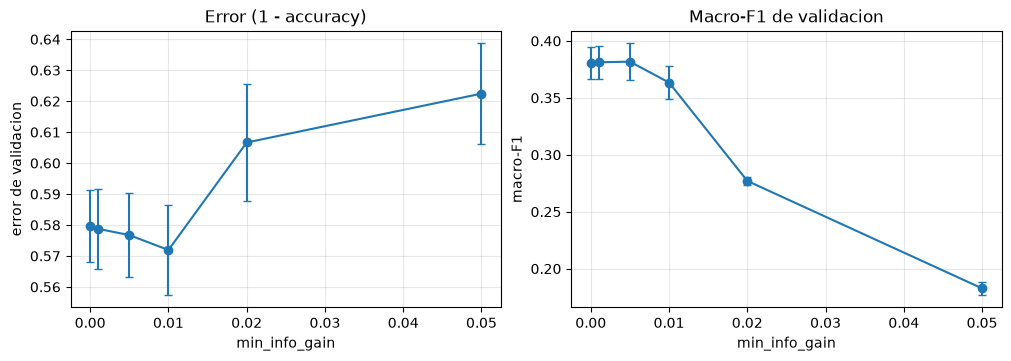

min_info_gain elegido: 0.005
Con ese umbral el arbol tiene profundidad 6 y 589 hojas


In [7]:
grid_gain = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]
filas_id3 = []
for ganancia in grid_gain:
    detalle = evaluate_temporal_cv(
        ID3(min_info_gain=ganancia), train, folds, 'discrete'
    )
    arbol_tmp = ID3(min_info_gain=ganancia).fit(X_train, train['winner'])
    filas_id3.append({
        'min_info_gain': ganancia,
        'error_validacion': detalle.validation_error.mean(),
        'error_validacion_std': detalle.validation_error.std(ddof=0),
        'macro_f1': detalle.macro_f1.mean(),
        'macro_f1_std': detalle.macro_f1.std(ddof=0),
        'error_train': detalle.train_error.mean(),
        'profundidad': arbol_tmp.get_depth(),
        'hojas': arbol_tmp.get_n_leaves(),
    })
cv_id3 = pd.DataFrame(filas_id3)
display(cv_id3.round(6))

fig, ejes = plt.subplots(1, 2, figsize=(10, 3.5), layout='constrained')
ejes[0].errorbar(cv_id3['min_info_gain'], cv_id3['error_validacion'],
                 yerr=cv_id3['error_validacion_std'], marker='o', capsize=3)
ejes[0].set(xlabel='min_info_gain', ylabel='error de validacion',
            title='Error (1 - accuracy)')
ejes[1].errorbar(cv_id3['min_info_gain'], cv_id3['macro_f1'],
                 yerr=cv_id3['macro_f1_std'], marker='o', capsize=3)
ejes[1].set(xlabel='min_info_gain', ylabel='macro-F1',
            title='Macro-F1 de validacion')
for eje in ejes:
    eje.grid(alpha=0.3)
plt.show()

id3_gain = float(
    cv_id3.sort_values(['macro_f1', 'min_info_gain'],
                       ascending=[False, True]).iloc[0]['min_info_gain']
)
fila_elegida = cv_id3[cv_id3['min_info_gain'] == id3_gain].iloc[0]
print('min_info_gain elegido:', id3_gain)
print(f'Con ese umbral el arbol tiene profundidad {fila_elegida["profundidad"]:.0f} '
      f'y {fila_elegida["hojas"]:.0f} hojas')

Vemos la misma medicion de dos formas. El error de validacion (1 - accuracy)
baja hasta `min_info_gain = 0.01` y despues sube; el macro-F1 tiene su maximo en
`0.005` y cae desde `0.01`. Elegimos por macro-F1 porque no queremos un arbol que
ignore las clases minoritarias. Entre `0.0` y `0.005` la diferencia de macro-F1
(≈0.001) es mucho menor que la desviacion entre folds (≈0.015), asi que esos
valores no se distinguen con estos datos; `0.005` es el maximo nominal, y ademas
poda algo (589 hojas contra 644). A partir de `0.02` el arbol queda demasiado
podado y el rendimiento cae fuerte.

## 9. ID3: entrenar y medir sobre el test

Con el umbral elegido entrenamos el arbol con todo el train y lo evaluamos por
primera vez sobre 2024-2025. `classification_report` da, para cada clase,
**precision**, **recall**, **F1** y **support**, y dos promedios (macro y
weighted); la **matriz de confusion** los muestra por clase: filas = real,
columnas = predicho. Tambien reportamos la importancia de cada atributo
(ganancia acumulada normalizada) para ver que usa el arbol.

Accuracy: 0.4661
Macro-F1: 0.4027
Profundidad: 6 | hojas: 589
### ID3 propio
              precision    recall  f1-score   support

           E     0.3214    0.1374    0.1925       131
           L     0.4757    0.7737    0.5892       190
           V     0.5140    0.3642    0.4264       151

    accuracy                         0.4661       472
   macro avg     0.4371    0.4251    0.4027       472
weighted avg     0.4452    0.4661    0.4270       472



,atributo,importancia
5,home_win_rate_h2h_as_home,0.274266
0,home_win_rate_last_5,0.178353
2,home_win_rate_season,0.163432
1,away_win_rate_last_5,0.155606
3,away_win_rate_season,0.131259
4,home_win_rate_as_home_all,0.097084


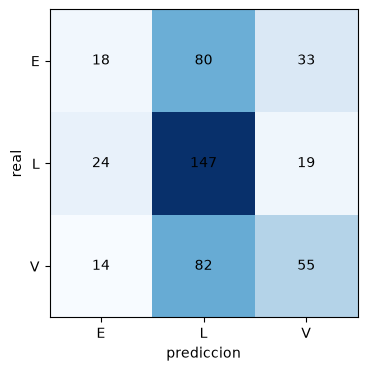

In [8]:
arbol_id3 = ID3(min_info_gain=id3_gain)
arbol_id3.fit(X_train, train['winner'])

y_test = test['winner'].to_numpy()
y_pred = arbol_id3.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('Macro-F1:', round(
    f1_score(y_test, y_pred, average='macro', zero_division=0), 4))
print('Profundidad:', arbol_id3.get_depth(), '| hojas:', arbol_id3.get_n_leaves())
reporte_por_clases('ID3 propio', y_test, y_pred)

importancias = pd.DataFrame({
    'atributo': NUMERIC_FEATURES,
    'importancia': arbol_id3.feature_importances_,
}).sort_values('importancia', ascending=False)
display(importancias)

matriz = confusion_matrix(y_test, y_pred, labels=CLASSES)
fig, axis = plt.subplots(figsize=(4.5, 4))
axis.imshow(matriz, cmap='Blues')
axis.set(xticks=range(3), xticklabels=CLASSES,
         yticks=range(3), yticklabels=CLASSES,
         xlabel='prediccion', ylabel='real')
for fila in range(3):
        for col in range(3):
            axis.text(col, fila, str(matriz[fila, col]),
                      ha='center', va='center')
plt.show()

La diagonal son los aciertos y lo que queda afuera son errores. Se ve el patron
que anticipamos: el ID3 casi siempre dice `L`. De los 190 `L` reales acierta 147
(77%), pero de los 131 empates solo pesca 18 (14%) y de los 151 `V`, 55 (36%). Los
empates se pierden casi todos porque su fila queda casi sin diagonal; cuando dice
`L` acierta el 48% de las veces, por eso el accuracy es 0.4661 pero el macro-F1
0.4027. Esta matriz es el contraste con el Naive Bayes de la seccion 13.

## 10. Ejemplos: donde acierta y donde falla

Vemos partidos reales de test con la prediccion. La columna `acierta` indica
si el arbol acerto. Los empates son la clase que mas se pierde.

In [9]:
predicciones = test[['date', 'home', 'away', 'winner']].copy()
predicciones['prediccion_id3'] = y_pred
predicciones['acierta'] = predicciones['prediccion_id3'] == predicciones['winner']
display(predicciones.sample(8, random_state=RANDOM_STATE))
print('Aciertos totales:', int(predicciones['acierta'].sum()), '/', len(predicciones))

empates_reales = predicciones[predicciones['winner'] == 'E']
print('Sobre los', len(empates_reales), 'empates reales del test, '
      f'ID3 predijo empate en '
      f'{(empates_reales["prediccion_id3"] == "E").sum()} '
      f'({(empates_reales["prediccion_id3"] == "E").mean():.1%}).')
display(empates_reales.head(3))

,date,home,away,winner,prediccion_id3,acierta
55,2024-04-13,CA Cerro,CA Fenix,E,L,False
73,2024-04-27,Rampla Juniors Futbol Club,Deportivo Maldonado,E,L,False
33,2024-03-23,Nacional,CA Progreso,E,L,False
278,2024-11-18,CA Progreso,CA Fenix,E,V,False
244,2024-10-20,Cerro Largo FC,Danubio,E,L,False
380,2025-04-13,Boston River,Cerro Largo FC,L,L,True
211,2024-09-29,Defensor Sporting,Deportivo Maldonado,L,L,True
9,2024-02-24,Montevideo Wanderers,Racing Club,V,E,False


Aciertos totales: 220 / 472
Sobre los 131 empates reales del test, ID3 predijo empate en 18 (13.7%).


,date,home,away,winner,prediccion_id3,acierta
3,2024-02-18,CA Cerro,Montevideo Wanderers,E,L,False
5,2024-02-18,Racing Club,Liverpool,E,V,False
8,2024-02-24,Boston River,Danubio,E,L,False


### 10.1. Prediccion de un partido nuevo

Para demostrar que un modelo entrenado sirve para clasificar una instancia
nueva, `predict_new_match` (definida en la seccion 1.2) aplica a un partido
hipotetico exactamente el mismo calculo de atributos del resto del notebook:
solo partidos anteriores, los mismos calculos y la misma imputacion neutra si
no hay historial. No se reimplementan tasas ni se le pasa ningun resultado.

Tomamos tres partidos futuros (no estan en el dataset) y los clasificamos con
dos modelos ya entrenados: el ID3 propio (discretizado) y el clasificador base
(tasas crudas). No buscamos optimizar nada, solo mostrar el uso.


In [10]:

base_demo = TenYearWinRateClassifier().fit(
    train[BASELINE_FEATURES], train['winner'])

partidos_nuevos = [
    ('Nacional', 'CA Penarol', '2025-11-16'),
    ('Boston River', 'Torque FC', '2025-11-16'),
    ('CA Juventud', 'Plaza Colonia', '2025-11-16'),
]

filas_demo = []
for home, away, fecha in partidos_nuevos:
    id3_demo = predict_new_match(
        home, away, fecha, matches, arbol_id3,
        feature_columns=NUMERIC_FEATURES, discretizer=discretizer)
    base_demo_pred = predict_new_match(
        home, away, fecha, matches, base_demo,
        feature_columns=BASELINE_FEATURES, discretizer=None)
    filas_demo.append({
        'fecha': fecha,
        'partido': f'{home} vs {away}',
        'forma local': round(id3_demo['features']['home_win_rate_last_5'], 2),
        'forma visitante': round(id3_demo['features']['away_win_rate_last_5'], 2),
        'h2h local': round(id3_demo['features']['home_win_rate_h2h_as_home'], 2),
        'ID3': id3_demo['prediccion'],
        'Base 10 anios': base_demo_pred['prediccion'],
    })
display(pd.DataFrame(filas_demo))


## 11. Comparadores

Comparamos el ID3 propio con:

- `sklearn DecisionTree` con el mismo input discretizado: sirve para comparar
  nuestra implementacion con la de la biblioteca, con el mismo input para las
  dos.
- `sklearn DecisionTree` con las tasas crudas: puede cortar en cualquier
  umbral, muestra cuanto gana un arbol sobre el input continuo.
- `sklearn RandomForest` (300 arboles, `class_weight='balanced_subsample'`):
  el bosque da mas peso a las clases chicas en cada arbol para no ignorar el
  empate. Es una referencia alta, no una competencia directa.
- El clasificador base: gana el equipo con mayor proporcion de victorias en
  los ultimos diez anos (una regla fija, sin aprendizaje).

Todos se entrenan solo con train y se evaluan sobre el mismo test de
2024-2025; la tabla compara accuracy y macro-F1 (seccion 7).

In [11]:
X_train_raw = train[NUMERIC_FEATURES].to_numpy()
X_test_raw = test[NUMERIC_FEATURES].to_numpy()
y_train = train['winner'].to_numpy()

competidores = {
    'sklearn DT (mismo input)': DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE),
    'sklearn DT (tasas crudas)': DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE),
    'sklearn RandomForest (tasas crudas)': RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample', random_state=RANDOM_STATE),
}

filas_comp = []
predicciones_comp = {}
for nombre, modelo in competidores.items():
    usa_codigos = 'mismo input' in nombre
    X_entrena = X_train if usa_codigos else X_train_raw
    X_prueba = X_test if usa_codigos else X_test_raw
    modelo.fit(X_entrena, y_train)
    predicha = modelo.predict(X_prueba)
    predicciones_comp[nombre] = predicha
    filas_comp.append({
        'modelo': nombre,
        'accuracy': round(accuracy_score(y_test, predicha), 4),
        'macro_f1': round(
            f1_score(y_test, predicha, average='macro', zero_division=0), 4),
    })

base_10 = TenYearWinRateClassifier()
base_10.fit(train[BASELINE_FEATURES], train['winner'])
pred_base = base_10.predict(test[BASELINE_FEATURES])
filas_comp.append({
    'modelo': 'Base 10 anios (clasificador base)',
    'accuracy': round(accuracy_score(y_test, pred_base), 4),
    'macro_f1': round(
        f1_score(y_test, pred_base, average='macro', zero_division=0), 4),
})
filas_comp.append({
    'modelo': 'ID3 propio',
    'accuracy': round(accuracy_score(y_test, y_pred), 4),
    'macro_f1': round(
        f1_score(y_test, y_pred, average='macro', zero_division=0), 4),
})
display(pd.DataFrame(filas_comp))

,modelo,accuracy,macro_f1
0,sklearn DT (mismo input),0.4682,0.4109
1,sklearn DT (tasas crudas),0.3602,0.3514
2,sklearn RandomForest (tasas crudas),0.4386,0.4085
3,Base 10 anios (clasificador base),0.4619,0.3564
4,ID3 propio,0.4661,0.4027


## 12. Naive Bayes propio

Naive Bayes combina la frecuencia de cada clase con la de sus atributos,
asumiendo independencia entre atributos dada la clase. Nuestra implementacion
(`MEstimateCategoricalNB`) usa suavizado m-estimate:

$$
P(X_j = v \mid Y = c) = \frac{n_{jvc} + m \cdot p_{jv}}{n_c + m}
$$

con un prior uniforme de categorias `p_jv = 1 / K_j` (K_j = 4: tres bines mas
el 0 reservado). `m` agrega conteos artificiales y evita probabilidades
cero; cuanto mayor es `m`, mas se acerca a un prior uniforme y menos pesa la
frecuencia observada.

`CategoricalNB` de scikit-learn estima `(n + alpha) / (n_c + alpha * K)`, que
coincide con la nuestra tomando `alpha = m / 4`. Por eso barremos `m` sobre la
validacion y repetimos la grilla con `CategoricalNB(m/4)`, confirmando la
equivalencia problema a problema.

Elegimos el `m` que maximiza el macro-F1 de validacion, con el mismo desempate
que en ID3: ante valores que rinden igual, el menor `m` (no agregamos
suavizado artificial del que los datos no dan evidencia). Las columnas `*_std`
son la desviacion estandar entre los tres folds y `error_validacion` es
`1 - accuracy` (seccion 7).

,m,alpha,error_validacion,error_validacion_std,macro_f1,macro_f1_sklearn,macro_f1_std
0,0.1,0.025,0.565633,0.035400,0.363482,0.363482,0.032202
1,1.0,0.250,0.565633,0.035400,0.363482,0.363482,0.032202
2,10.0,2.500,0.565633,0.035400,0.363482,0.363482,0.032202
3,100.0,25.000,0.567146,0.038048,0.358941,0.358941,0.033387
4,1000.0,250.000,0.566571,0.029783,0.334176,0.334176,0.022262


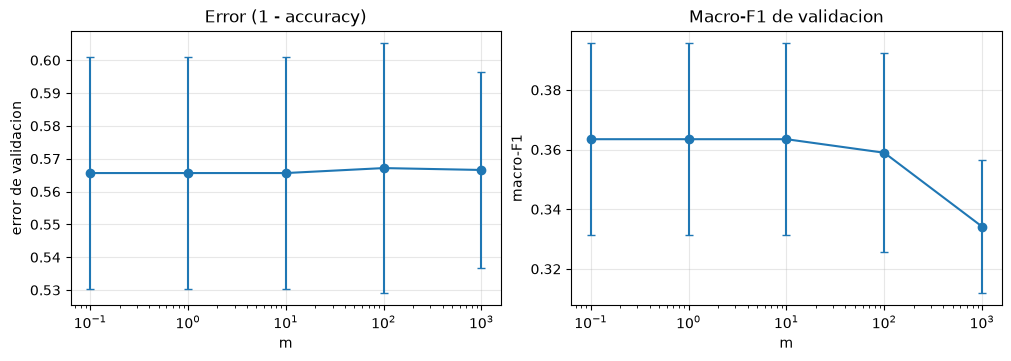

m elegido: 0.1 -> alpha = 0.025


In [12]:
grid_m = [0.1, 1, 10, 100, 1000]
filas_nb = []
for m in grid_m:
    propio = evaluate_temporal_cv(
        MEstimateCategoricalNB(m=m, min_categories=4), train, folds, 'discrete')
    referencia = evaluate_temporal_cv(
        CategoricalNB(alpha=m / 4, min_categories=4, force_alpha=True),
        train, folds, 'discrete')
    filas_nb.append({
        'm': m,
        'alpha': m / 4,
        'error_validacion': propio.validation_error.mean(),
        'error_validacion_std': propio.validation_error.std(ddof=0),
        'macro_f1': propio.macro_f1.mean(),
        'macro_f1_sklearn': referencia.macro_f1.mean(),
        'macro_f1_std': propio.macro_f1.std(ddof=0),
    })
cv_nb = pd.DataFrame(filas_nb)
display(cv_nb.round(6))

fig, ejes = plt.subplots(1, 2, figsize=(10, 3.5), layout='constrained')
ejes[0].errorbar(cv_nb['m'], cv_nb['error_validacion'],
                 yerr=cv_nb['error_validacion_std'], marker='o', capsize=3)
ejes[0].set(xscale='log', xlabel='m', ylabel='error de validacion',
            title='Error (1 - accuracy)')
ejes[1].errorbar(cv_nb['m'], cv_nb['macro_f1'],
                 yerr=cv_nb['macro_f1_std'], marker='o', capsize=3)
ejes[1].set(xscale='log', xlabel='m', ylabel='macro-F1',
            title='Macro-F1 de validacion')
for eje in ejes:
    eje.grid(alpha=0.3)
plt.show()

nb_m = float(
    cv_nb.sort_values(['macro_f1', 'm'], ascending=[False, True]).iloc[0]['m']
)
print('m elegido:', nb_m, '-> alpha =', nb_m / 4)

La misma medicion que en la seccion 8, ahora variando `m` en escala
logaritmica. De `0.1` a `10` el error (0.5656) y el macro-F1 (0.3635) no cambian:
con `m` chico el suavizado apenas pesa. Recien desde `m = 100` el macro-F1 empieza
a bajar (0.3589) y con `m = 1000` cae a 0.3342, porque el suavizado tira las
probabilidades hacia la uniforme y aplana lo que dicen los datos. Como la
validacion no distingue entre `0.1`, `1` y `10`, elegimos el menor `m` de la grilla
(el desempate de la seccion 12): agregamos el minimo suavizado artificial. Ademas,
`macro_f1_sklearn` coincide con la nuestra fila por fila, que es la evidencia de
que la implementacion propia equivale a `CategoricalNB(alpha = m / 4)`.

## 13. Naive Bayes final sobre el test

Con el `m` ya fijado probamos si conviene sumar cuatro atributos mas: los
promedios por partido de puntos y de diferencia de gol de los ultimos cinco
partidos de cada equipo (`plus_points_and_goals`). Usamos el **mismo `m`
elegido antes** y la misma validacion temporal: primero se elige el
hiperparametro del modelo y recien despues se comparan conjuntos de atributos,
para no mezclar ambas decisiones. Si la variante de diez
columnas no mejora el macro-F1 de validacion, no la usamos. El modelo final se
ajusta con todo el train, se evalua el test y se compara con el baseline.

,atributos,macro_f1_validacion
0,6 tasas,0.356222
1,+ puntos y diferencia de gol (10),0.381478


Variante elegida: + puntos y diferencia de gol (10)
Same predictions (propio vs CategoricalNB): True
Accuracy NB: 0.4619
Macro-F1 NB: 0.4281
### NB propio (10 atributos)
              precision    recall  f1-score   support

           E     0.3068    0.2061    0.2466       131
           L     0.5336    0.6263    0.5763       190
           V     0.4472    0.4768    0.4615       151

    accuracy                         0.4619       472
   macro avg     0.4292    0.4364    0.4281       472
weighted avg     0.4430    0.4619    0.4481       472



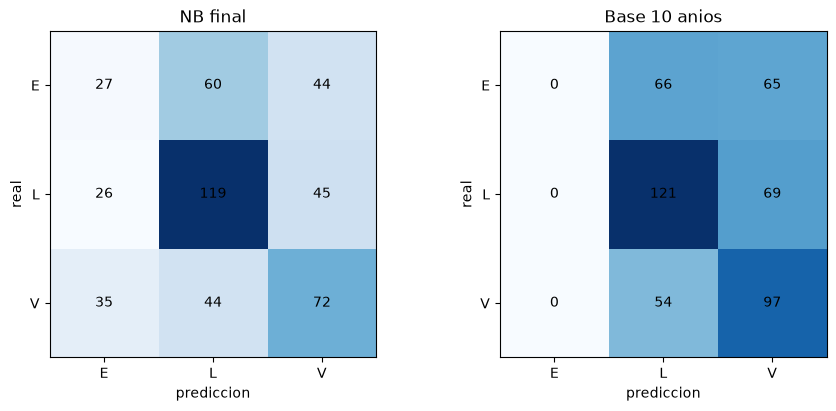

In [13]:
columnas_final = NUMERIC_FEATURES + [
    'home_points_per_match_5', 'away_points_per_match_5',
    'home_goal_diff_per_match_5', 'away_goal_diff_per_match_5',
]


def macro_f1_validacion(columnas):
    """Macro-F1 medio de validacion de MEstimateCategoricalNB con m fijo."""
    resultados = []
    for fold in folds:
        tr = train.iloc[list(fold.train_positions)]
        va = train.iloc[list(fold.validation_positions)]
        disc = MixedTypeDiscretizer(
            [], list(columnas), n_bins=3,
            fixed_cuts={c: [0.3, 0.6] for c in NUMERIC_FEATURES if c in columnas},
        )
        disc.fit(tr[list(columnas)])
        modelo = MEstimateCategoricalNB(m=nb_m, min_categories=4).fit(
            disc.transform(tr[list(columnas)]), tr['winner'])
        pred = modelo.predict(disc.transform(va[list(columnas)]))
        resultados.append(f1_score(va['winner'], pred,
                                   average='macro', zero_division=0))
    return float(np.mean(resultados))


comparacion_cols = pd.DataFrame([
    {'atributos': '6 tasas', 'macro_f1_validacion': macro_f1_validacion(NUMERIC_FEATURES)},
    {'atributos': '+ puntos y diferencia de gol (10)', 'macro_f1_validacion': macro_f1_validacion(columnas_final)},
])
display(comparacion_cols.round(6))
usar_final = comparacion_cols.sort_values(
    'macro_f1_validacion', ascending=False).iloc[0]['atributos']
print('Variante elegida:', usar_final)

disc_final = MixedTypeDiscretizer(
    [], columnas_final, n_bins=3,
    fixed_cuts={c: [0.3, 0.6] for c in NUMERIC_FEATURES},
)
disc_final.fit(train[columnas_final])
Xnb_train = disc_final.transform(train[columnas_final])
Xnb_test = disc_final.transform(test[columnas_final])

nb_final = MEstimateCategoricalNB(m=nb_m, min_categories=4).fit(
    Xnb_train, train['winner'])
nb_ref = CategoricalNB(alpha=nb_m / 4, min_categories=4, force_alpha=True).fit(
    Xnb_train, train['winner'])

pred_nb = nb_final.predict(Xnb_test)
pred_ref = nb_ref.predict(Xnb_test)
print('Same predictions (propio vs CategoricalNB):',
      bool((pred_nb == pred_ref).all()))
print('Accuracy NB:', round(accuracy_score(y_test, pred_nb), 4))
print('Macro-F1 NB:', round(
    f1_score(y_test, pred_nb, average='macro', zero_division=0), 4))
reporte_por_clases('NB propio (10 atributos)', y_test, pred_nb)

fig, ejes = plt.subplots(1, 2, figsize=(9, 4), layout='constrained')
for eje, (nombre, pred) in zip(ejes, [('NB final', pred_nb),
                                      ('Base 10 anios', pred_base)]):
    matriz = confusion_matrix(y_test, pred, labels=CLASSES)
    eje.imshow(matriz, cmap='Blues')
    eje.set(xticks=range(3), xticklabels=CLASSES,
            yticks=range(3), yticklabels=CLASSES,
            xlabel='prediccion', ylabel='real', title=nombre)
    for fila in range(3):
        for col in range(3):
            eje.text(col, fila, str(matriz[fila, col]),
                     ha='center', va='center')
plt.show()

Los dos modelos tienen la misma accuracy (0.4619: aciertan 218 partidos de 472)
pero por caminos distintos. El NB reparte sus aciertos entre las tres clases:
atrapa 119 de los 190 `L`, 27 de los 131 empates y 72 de los 151 `V`; la base solo
mira `L` y `V` (121 y 97) y nunca `E`, asi que su fila de empates queda vacia. Esa
diferencia aparece en el macro-F1: 0.4281 del NB contra 0.3564 de la base. La base
llega a la misma accuracy jugando seguro con las clases grandes; el NB no deja
tirada la clase chica y por eso lo consideramos mejor.

## 14. Efectividad del algoritmo

Juntamos todo en una tabla sobre el mismo test y lo comparamos con la regla
trivial de predecir siempre L (la clase mayoritaria). Ademas vemos cuantos
empates captura cada modelo.

In [14]:
siempre_l = np.full(len(y_test), 'L')
filas_resumen = filas_comp + [
    {'modelo': 'NB propio (10 atributos)',
     'accuracy': round(accuracy_score(y_test, pred_nb), 4),
     'macro_f1': round(
         f1_score(y_test, pred_nb, average='macro', zero_division=0), 4)},
    {'modelo': 'Siempre L',
     'accuracy': round(accuracy_score(y_test, siempre_l), 4),
     'macro_f1': round(
         f1_score(y_test, siempre_l, average='macro', zero_division=0), 4)},
]
resumen = pd.DataFrame(filas_resumen)
display(resumen.sort_values('accuracy', ascending=False).reset_index(drop=True))

print('Empates reales en test:', int((y_test == 'E').sum()),
      'de', len(y_test))
for nombre, pred in [('ID3', y_pred), ('NB final', pred_nb),
                     ('Base 10 anios', pred_base)]:
    print(f'{nombre:<15} predijo E en '
          f'{int((pred == "E").sum())} partidos '
          f'(acierto {(pred[y_test == "E"] == "E").mean():.1%} de los reales)')

,modelo,accuracy,macro_f1
0,sklearn DT (mismo input),0.4682,0.4109
1,ID3 propio,0.4661,0.4027
2,Base 10 anios (clasificador base),0.4619,0.3564
3,NB propio (10 atributos),0.4619,0.4281
4,sklearn RandomForest (tasas crudas),0.4386,0.4085
5,Siempre L,0.4025,0.1913
6,sklearn DT (tasas crudas),0.3602,0.3514


Empates reales en test: 131 de 472
ID3             predijo E en 56 partidos (acierto 13.7% de los reales)
NB final        predijo E en 88 partidos (acierto 20.6% de los reales)
Base 10 anios   predijo E en 0 partidos (acierto 0.0% de los reales)


### 14.1. Metricas por clase de los cinco modelos

La misma funcion `reporte_por_clases` mide a los cinco modelos sobre el mismo
test. Ya la usamos arriba para ID3 y NB propio; la repetimos aca con todos los
comparadores para ver de un vistazo como rinde cada clase (definiciones en la
seccion 7).

In [15]:
reporte_por_clases('Base 10 anios', y_test, pred_base)
reporte_por_clases('sklearn DT (mismo input)', y_test,
                   predicciones_comp['sklearn DT (mismo input)'])
reporte_por_clases('sklearn RandomForest (tasas crudas)', y_test,
                   predicciones_comp['sklearn RandomForest (tasas crudas)'])
reporte_por_clases('sklearn CategoricalNB', y_test, pred_ref)

### Base 10 anios
              precision    recall  f1-score   support

           E     0.0000    0.0000    0.0000       131
           L     0.5021    0.6368    0.5615       190
           V     0.4199    0.6424    0.5079       151

    accuracy                         0.4619       472
   macro avg     0.3073    0.4264    0.3564       472
weighted avg     0.3364    0.4619    0.3885       472

### sklearn DT (mismo input)
              precision    recall  f1-score   support

           E     0.3281    0.1603    0.2154       131
           L     0.4801    0.7632    0.5894       190
           V     0.5189    0.3642    0.4280       151

    accuracy                         0.4682       472
   macro avg     0.4424    0.4292    0.4109       472
weighted avg     0.4503    0.4682    0.4340       472

### sklearn RandomForest (tasas crudas)
              precision    recall  f1-score   support

           E     0.3298    0.2366    0.2756       131
           L     0.4722    0.6263    0.538

'              precision    recall  f1-score   support\n\n           E     0.3068    0.2061    0.2466       131\n           L     0.5336    0.6263    0.5763       190\n           V     0.4472    0.4768    0.4615       151\n\n    accuracy                         0.4619       472\n   macro avg     0.4292    0.4364    0.4281       472\nweighted avg     0.4430    0.4619    0.4481       472\n'

### Como interpretar los resultados

1. Con tres clases un clasificador aleatorio rondaria el 33% de accuracy;
   predecir siempre L alcanza ~40% (L es la clase mayoritaria). El ID3 y el NB
   superan ambos baselines, aunque la ventaja sobre la regla de diez anos es
   pequena: las tasas discretizadas no dan mucha mas informacion para separar
   las clases.
2. Los empates son la clase mas dificil. Son ~28% de los datos y su recall
   queda entre 17% y 22%: de cada cinco empates reales los modelos pescan uno o
   poco mas. Las tasas de victoria no discriminan empates, que quedan diluidos
   en las hojas/nodos que eligen la opcion de menor riesgo. En contraste, la
   precision de L es alta: cuando el modelo dice L acierta bastante; el
   problema es que predice L de mas y se pierde empates.
3. Tres atributos concentran casi toda la ganancia: la forma de los ultimos
   cinco partidos y el historial local. La poda con `min_info_gain` actua:
   sin poda el arbol crece hasta ~645 hojas (memoriza ruido); el umbral
   elegido baja a ~589 hojas con el mejor macro-F1 de validacion, y al subir
   mas el umbral (0.02+) el macro-F1 colapsa porque el arbol ya no separa ni
   las clases grandes.
4. NB con diez atributos aprovecha mejor las tasas numericas y, a diferencia
   del baseline, predice empates: no gana siempre, pero en la medicion final
   queda por delante tanto en accuracy como en macro-F1, sin dejar tirada
   ninguna clase.
5. Los numeros son de confiar porque los hiperparametros se eligieron con la
   validacion temporal (folds 2021-2023) y el test de 2024-2025 se uso una
   sola vez, al final, para medir; no se ajusto nada mirando el test.